In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_datam=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1 (1).csv',sep=',',encoding='latin1')
raw_datam.rename(columns={'Unnamed: 1':'Message Type',
                                 'Unnamed: 2':'Protocole',
                                 'Unnamed: 3':'IMEI',
                                 'Unnamed: 4':'Serial',
                                 'Unnamed: 5':'Mileage',
                                 'Unnamed: 6':'Date',
                                 'Unnamed: 7':'Ignition',
                                 'Unnamed: 8':'Latitude',
                                 'Unnamed: 9':'Longitude',
                                 'Unnamed: 10':'Altitude',
                                 'Unnamed: 11':'External Power',
                                 'Unnamed: 12':'RPM',
                                 'Unnamed: 13':'Speed',
                                 'Unnamed: 14':'Satellite Number',
                                 'Unnamed: 15':'Azimuth',
                                 'Unnamed: 16':'Bettery level',
                                 },inplace=True)
raw_datam.info()
raw_datam.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_.csv')

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Message           116 non-null    str  
 1   Message Type      116 non-null    str  
 2   Protocole         116 non-null    str  
 3   IMEI              116 non-null    str  
 4   Serial            116 non-null    str  
 5   Mileage           116 non-null    str  
 6   Date              116 non-null    str  
 7   Ignition          116 non-null    str  
 8   Latitude          116 non-null    str  
 9   Longitude         116 non-null    str  
 10  Altitude          116 non-null    str  
 11  External Power    115 non-null    str  
 12  RPM               115 non-null    str  
 13  Speed             114 non-null    str  
 14  Satellite Number  114 non-null    str  
 15  Azimuth           114 non-null    str  
 16  Bettery level     114 non-null    str  
 17  Unnamed: 17       2 non-null      str  
 18  U

In [40]:
raw_datam['Protocole'].value_counts()

Protocole
ProtocolHeadType:20    63
ProtocolHeadType:19    51
ProtocolHeadType:0      2
Name: count, dtype: int64

Odometer

In [41]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_.csv',sep=',')
unit['Odometer in meters']=0.0
unit.info()
unit_mileage=unit[unit['Date'].str.contains('2026-04-20T21')]
unit_mileage[['Mileage','Date','IMEI']]

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          116 non-null    int64  
 1   Message             116 non-null    str    
 2   Message Type        116 non-null    str    
 3   Protocole           116 non-null    str    
 4   IMEI                116 non-null    str    
 5   Serial              116 non-null    str    
 6   Mileage             116 non-null    str    
 7   Date                116 non-null    str    
 8   Ignition            116 non-null    str    
 9   Latitude            116 non-null    str    
 10  Longitude           116 non-null    str    
 11  Altitude            116 non-null    str    
 12  External Power      115 non-null    str    
 13  RPM                 115 non-null    str    
 14  Speed               114 non-null    str    
 15  Satellite Number    114 non-null    str    
 16  Azimuth            

,Mileage,Date,IMEI


In [42]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_.csv',sep=',')
unit_mileage=unit[unit['Date'].str.contains('2026-04-20T:')]
unit_mileage[['Mileage','Date','IMEI']]

,Mileage,Date,IMEI


In [43]:
unit_odometer=unit[~unit['Protocole'].str.contains(':0')]
unit_odometer['Protocole'].value_counts()

Protocole
ProtocolHeadType:20    63
ProtocolHeadType:19    51
Name: count, dtype: int64

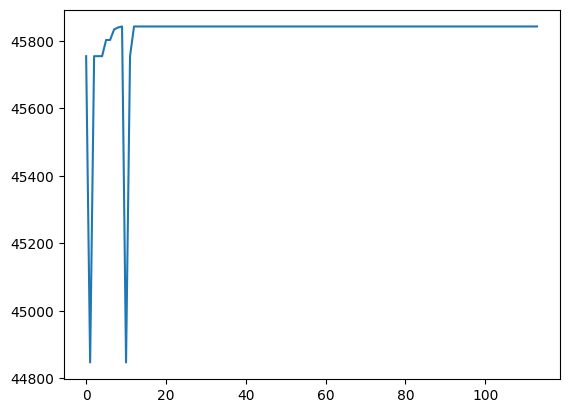

In [44]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit_odometer.iloc[i,6][8:15]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(133,171):
#    print(date[i],' -> ',x_axis[i],y_axis[i])

#plt.ylim(5230627,5240177)
#plt.xlim(133,171)
#plt.yticks(range(5230627,5240177,500))
#plt.xticks(range(133,171,5),rotation=90)
plt.plot(x_axis,y_axis)

In/outs

PS I0 I1 I2 I3 I4 I5 DI0
15 14 13 12 11 10 09 08 07 06 05 04 03 02 01 00
 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 1  1  1  0  0  0  0  1  0  0  0  0  0  0  0  0
 0  1  1  0  0  0  0  1  0  0  0  0  0  0  0  0

In [45]:
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])
        #print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])
        print(raw_data.iloc[i,2][64:68],bin(int(raw_data.iloc[i,2][64:68],16)),' -> ',raw_data.iloc[i,0])
    
for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='1000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(2)
        #print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='2000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(1)
        #print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

raw_data_df['Date']=aux_date
raw_data_df['raw_data']=aux_raw_data
raw_data_df['Input']=aux_input_number

#raw_data_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_to_jira.csv')

    

0100 0b100000000  ->  2026-04-29 13:16:44.906
4100 0b100000100000000  ->  2026-04-29 13:28:10.414
2100 0b10000100000000  ->  2026-04-29 13:37:11.866
0100 0b100000000  ->  2026-04-29 13:37:33.879
2100 0b10000100000000  ->  2026-04-29 13:40:39.486
2100 0b10000100000000  ->  2026-04-29 13:41:27.899
0100 0b100000000  ->  2026-04-29 13:42:25.890
0100 0b100000000  ->  2026-04-29 14:47:44.113
0100 0b100000000  ->  2026-04-29 14:58:47.773
0100 0b100000000  ->  2026-04-29 14:58:50.569
4100 0b100000100000000  ->  2026-04-29 15:10:19.638
2100 0b10000100000000  ->  2026-04-29 15:21:57.234
2100 0b10000100000000  ->  2026-04-29 15:56:51.058
0100 0b100000000  ->  2026-04-29 15:57:05.246
0100 0b100000000  ->  2026-04-29 16:02:31.717
4100 0b100000100000000  ->  2026-04-29 16:26:59.178
6100 0b110000100000000  ->  2026-04-29 16:27:38.816
4100 0b100000100000000  ->  2026-04-29 16:27:52.826
4100 0b100000100000000  ->  2026-04-29 16:29:04.885
4100 0b100000100000000  ->  2026-04-29 16:30:03.732
4100 0b100000